# H-Reflex Post-Hoc Analysis

Loads peri-stimulus trial files from the H-Reflex App and runs the full post-hoc analysis pipeline.

**File convention (V2/V3):**
- **`.hrs1`** — MH Recruitment Curve stage (sweeps intensities)
- **`.hrs2`** — Control Mode stage (fixed intensity, user-adjustable)
- **`.hrs3`** — Down Condition Pellet (DCP) stage
- **`.hrs4`** — Up Condition Pellet stage
- **`.hrs5`** — Down Condition VNS stage
- **`.hrs6`** — Up Condition VNS stage

# Section 1: Setup

Import all analysis utilities from `helpers.py`.

In [24]:
import os
import numpy as np
from helpers import (
    # Multi-recording loading
    load_all_recordings, build_settings_dataframe,
    plot_amplitude_distribution, plot_actual_trial_timeline,
    filter_failed_trials,
    plot_hrs2_analysis, plot_hrs2_trials,
    plot_background_grand_means,
    compute_trial_bins, filter_trials, compute_equal_bin_ranges,
    build_merged_amp_groups,
    plot_bin_overview, create_bin_viewer, print_bin_statistics,
    split_trials_by_polarity, plot_hm_ratio_summary,
    compute_snr_analysis, compute_mra_snr_analysis,
    SAMPLE_RATE, BIN_DURATION_MS, BIN_SAMPLES, TRIAL_RECORD_MS,
    STIM_ONSET_THRESHOLD, STIM_END_THRESHOLD,
)

print("Helpers loaded.")
print(f"  App constants: SAMPLE_RATE={SAMPLE_RATE} Hz | BIN={BIN_DURATION_MS} ms ({BIN_SAMPLES} samples) | TRIAL_RECORD={TRIAL_RECORD_MS} ms")
print(f"  Stim thresholds: onset >= {STIM_ONSET_THRESHOLD} V | end < {STIM_END_THRESHOLD} V")

Helpers loaded.
  App constants: SAMPLE_RATE=5000.0 Hz | BIN=50 ms (250 samples) | TRIAL_RECORD=100 ms
  Stim thresholds: onset >= 4.5 V | end < 1.9 V


# Section 2: Multi-Recording Configuration

Configure one or more recordings in `RECORDING_DIRS` below (label, folder path,
sample rate — `None` to auto-detect). The `.hrs1`–`.hrs6` and `.hrft` files in
each folder are found automatically.

In [25]:
# ── Multi-Recording Configuration ─────────────────────────────────────────────
# Each entry: ("Display Label", "relative/path/to/recording_dir", sample_rate_hz)
# sample_rate_hz: explicit Hz (e.g. 10000.0 or 5000.0); None = auto-detect from data.
RECORDING_DIRS = [
    # HRPilot-23 Recordings
    #("HRPILOT-23 250US",  "Calibration/HRPilot-23/CALIB1_HRPILOT-23_BOOTH2_250US_10KHZ_8-31-26",        10000.0),
    #("HRPILOT-23 100US",  "Calibration/HRPilot-23/CALIB2_HRPILOT-23_BOOTH3_100US_10KHZ_9-2-26",        10000.0),
    #("FT1 HRPILOT-23 250US",  "Calibration/HRPilot-23/FT1_HRPILOT-23_100US_10KHZ_9-8-26",        10000.0),
    #("Calib3 HRPILOT-23 100US",  "Calibration/HRPilot-23/CALIB3_HRPILOT-23_BOOTH3_100US_10KHZ_9-15-26",        10000.0),
    
    # HRPilot-25 Recordings
    #("HRPILOT-25 250US",  "Calibration/HRPilot-25/CALIB1_HRPILOT-25_BOOTH2_250US_10KHZ_8-25-26",        10000.0),
    #("HRPILOT-25 100US",  "Calibration/HRPilot-25/CALIB2_HRPILOT-25_BOOTH2_100US_10KHZ_9-2-26",        10000.0),
    #("Calib3 HRPILOT-25 250US",  "Calibration/HRPilot-25/CALIB3_HRPILOT-25_BOOTH1_250US_10KHZ_9-10-26",        10000.0),
    #("Calib4 HRPILOT-25 100US",  "Calibration/HRPilot-25/CALIB4_HRPILOT-25_BOOTH3_100US_10KHZ_9-14-26",        10000.0),
        
    
    # HRPilot-26 Recordings
    #("HRPILOT-26 250US",  "Calibration/HRPilot-26/CALIB1_HRPILOT-26_BOOTH2_250US_10KHZ_8-27-26",        10000.0),
    #("HRPILOT-26 100US",  "Calibration/HRPilot-26/CALIB2_HRPILOT-26_BOOTH1_100US_10KHZ_9-2-26",        10000.0),
    
    # HRPilot-34 Recordings
    #("HRPILOT-34 250US",  "Calibration/HRPilot-34/CALIB1_HRPILOT-34_BOOTH2_250US_10KHZ_9-2-26",        10000.0),
    #("Calib2 HRPILOT-34 250US",  "Calibration/HRPilot-34/CALIB2_HRPILOT-34_BOOTH2_250US_10KHZ_9-10-26",        10000.0),
    #("CM1 HRPILOT-34 250US",  "Calibration/HRPilot-34/CM1_HRPILOT-34_BOOTH1_250US_10KHZ_9-14-26",        10000.0),
    #("CM2 HRPILOT-34 250US",  "Calibration/HRPilot-34/CM2_HRPILOT-34_BOOTH1_250US_10KHZ_9-15-26",        10000.0),
    #("Calib3 HRPILOT-34 100US",  "Calibration/HRPilot-34/CALIB3_HRPILOT-34_BOOTH1_100US_10KHZ_9-15-26",        10000.0),
        
    
    # HRPilot-36 Recordings
    #("HRPILOT-36 250US",  "Calibration/HRPilot-36/CALIB1_HRPILOT-36_BOOTH3_250US_10KHZ_9-1-26",        10000.0),
    #("Calib2 HRPILOT-36 250US",  "Calibration/HRPilot-36/CALIB2_HRPILOT-36_BOOTH2_250US_10KHZ_9-10-26",        10000.0),
    #("CM1 HRPILOT-36 250US",  "Calibration/HRPilot-36/CM1_HRPILOT-36_BOOTH2_250US_10KHZ_9-14-26",        10000.0),
    ("CM2 HRPILOT-36 250US",  "Calibration/HRPilot-36/CM2_HRPILOT-36_BOOTH2_250US_10KHZ_9-15-26",        10000.0),
    
    
    # Add more recordings below — uncomment or append new tuples.
]
# When multiple recordings are loaded, pick which one to analyze with
# ACTIVE_RECORDING in the Recording & Stage Selector cell below.
print(f"{len(RECORDING_DIRS)} recording(s) configured.")
for _i, (_lbl, _rdir, _rsr) in enumerate(RECORDING_DIRS):
    _sr_str = f"{_rsr} Hz" if _rsr else "auto-detect"
    print(f"  [{_i}] {_lbl!r}  →  {_rdir}  (sample_rate={_sr_str})")

1 recording(s) configured.
  [0] 'CM2 HRPILOT-36 250US'  →  Calibration/HRPilot-36/CM2_HRPILOT-36_BOOTH2_250US_10KHZ_9-15-26  (sample_rate=10000.0 Hz)


# Section 3: Load Recordings & Select Stage

Load every recording in `RECORDING_DIRS`, then pick which recording/stage is
analyzed by the rest of this notebook via `ACTIVE_RECORDING` / `ACTIVE_STAGE`.

In [26]:
# ── Load all recordings (auto-detects V2 / V3) ─────────────────────────────────
_all_recordings = load_all_recordings(RECORDING_DIRS)
_active_rec_label = next(iter(_all_recordings))
print(f'\n{len(_all_recordings)} recording(s) loaded.  Active: {_active_rec_label!r}')


── Loading: 'CM2 HRPILOT-36 250US'  (Calibration/HRPilot-36/CM2_HRPILOT-36_BOOTH2_250US_10KHZ_9-15-26)
   .hrs1: not found
   .hrs2: 1591 trials  (Control Mode)
   Note: Control Mode aliased as primary analysis (no MH Recruitment stage).
   App V3  |  Stages: ['control_mode']  |  SR: 10000.0 Hz
   Settings sidecars: 1/1 stage(s)

1 recording(s) loaded.  Active: 'CM2 HRPILOT-36 250US'


In [27]:
# ── Recording & Stage Selector ─────────────────────────────────────────────────
# Change ACTIVE_RECORDING / ACTIVE_STAGE below, re-run this cell, then re-run any
# downstream analysis cells to apply the new selection.
ACTIVE_RECORDING = _active_rec_label   # or any label from RECORDING_DIRS

ACTIVE_STAGE = None   # None -> first available stage for the active recording
# ACTIVE_STAGE = 'mh_recruitment'        # MH Recruitment Curve  (.hrs1)
# ACTIVE_STAGE = 'control_mode'          # Control Mode          (.hrs2)
# ACTIVE_STAGE = 'dcp'                   # Down Condition Pellet (.hrs3)
# ACTIVE_STAGE = 'up_cond_pellet'        # Up Condition Pellet   (.hrs4)  [V3]
# ACTIVE_STAGE = 'down_cond_vns'         # Down Condition VNS    (.hrs5)  [V3]
# ACTIVE_STAGE = 'up_cond_vns'           # Up Condition VNS      (.hrs6)  [V3]
# ─────────────────────────────────────────────────────────────────────────────

if ACTIVE_RECORDING not in _all_recordings:
    print(f'Note: requested recording not available; defaulting to {_active_rec_label!r}')
    ACTIVE_RECORDING = _active_rec_label
_active_rec_label = ACTIVE_RECORDING

_rec_info  = _all_recordings[ACTIVE_RECORDING]
_stage_map = _rec_info['stage_map']
recording_sample_rate = _rec_info['sample_rate']
hrs1_header            = _rec_info['hrs1_header']

if ACTIVE_STAGE not in _stage_map:
    ACTIVE_STAGE = next(iter(_stage_map))
    print(f'Note: requested stage not available; defaulting to {ACTIVE_STAGE!r}')

_sel = _stage_map[ACTIVE_STAGE]
hrs2_trials, hrs2_header, hrs2_emg_blocks = _sel[0], _sel[1], _sel[2]

print(f'Recording : {ACTIVE_RECORDING!r}  (App V{_rec_info["app_version"]})')
print('Available stages:')
for _k, (_t, _h, _e, _lbl) in _stage_map.items():
    _mark = '  <- active' if _k == ACTIVE_STAGE else ''
    print(f'  {_k!r:<22} -> {_lbl}  ({len(_t)} trials){_mark}')
print(f'\nActive : {_sel[3]}  ->  {len(hrs2_trials)} trials')

Note: requested stage not available; defaulting to 'control_mode'
Recording : 'CM2 HRPILOT-36 250US'  (App V3)
Available stages:
  'control_mode'         -> Control Mode (.hrs2)  (1591 trials)  <- active

Active : Control Mode (.hrs2)  ->  1591 trials


# Section 4: Analysis Configuration

Set the M-wave and H-wave detection windows and viewing parameters used by all downstream sections.  
**Change these here** — every subsequent section picks them up automatically.

In [28]:
# Viewing windows (ms relative to stim onset)
PRE_PLOT_MS  = 5
POST_PLOT_MS = 25
PRE_AVG_MS   = 5
POST_AVG_MS  = 25
N_PER_PAGE   = 6

# M/H wave detection windows (ms relative to stim onset)
M_WAVE_START_MS =  1.8
M_WAVE_END_MS   =  4.5
H_WAVE_START_MS =  7
H_WAVE_END_MS   = 12

print(f"M-wave window : {M_WAVE_START_MS} – {M_WAVE_END_MS} ms")
print(f"H-wave window : {H_WAVE_START_MS} – {H_WAVE_END_MS} ms")
print(f"Plot window   : -{PRE_PLOT_MS} to +{POST_PLOT_MS} ms  |  Avg window: -{PRE_AVG_MS} to +{POST_AVG_MS} ms")

M-wave window : 1.8 – 4.5 ms
H-wave window : 7 – 12 ms
Plot window   : -5 to +25 ms  |  Avg window: -5 to +25 ms


# Section 5: Data Overview

Histogram of stimulation amplitudes delivered across the session and the actual inter-trial interval (ITI) timeline.

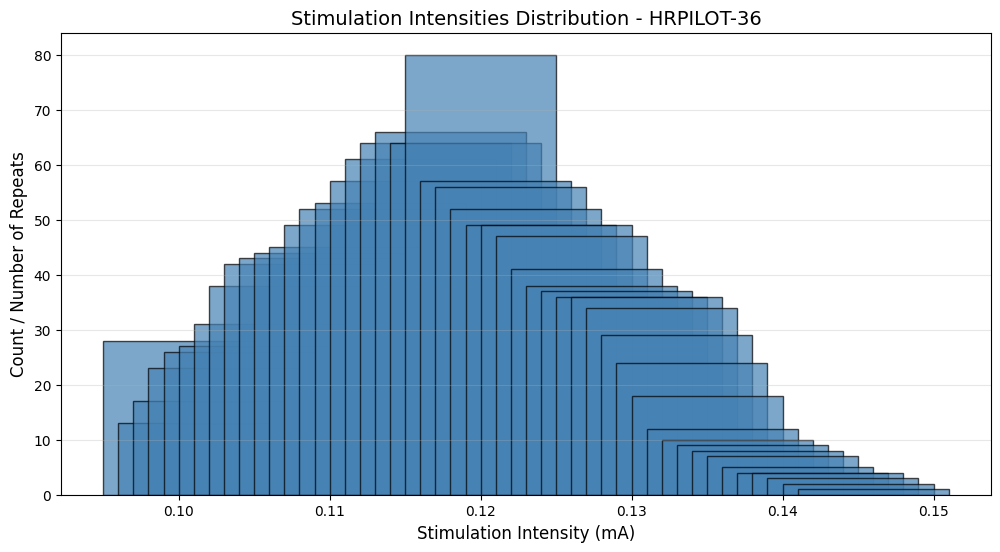

Actual trial timeline (1591 trials)
  Recording span : 14835.5 s  (4.121 h)
  Trial rate     : 386.1 trials / hour
  ITI — mean: 9330 ms  |  median: 5341 ms  |  min: 4651 ms  |  max: 257981 ms


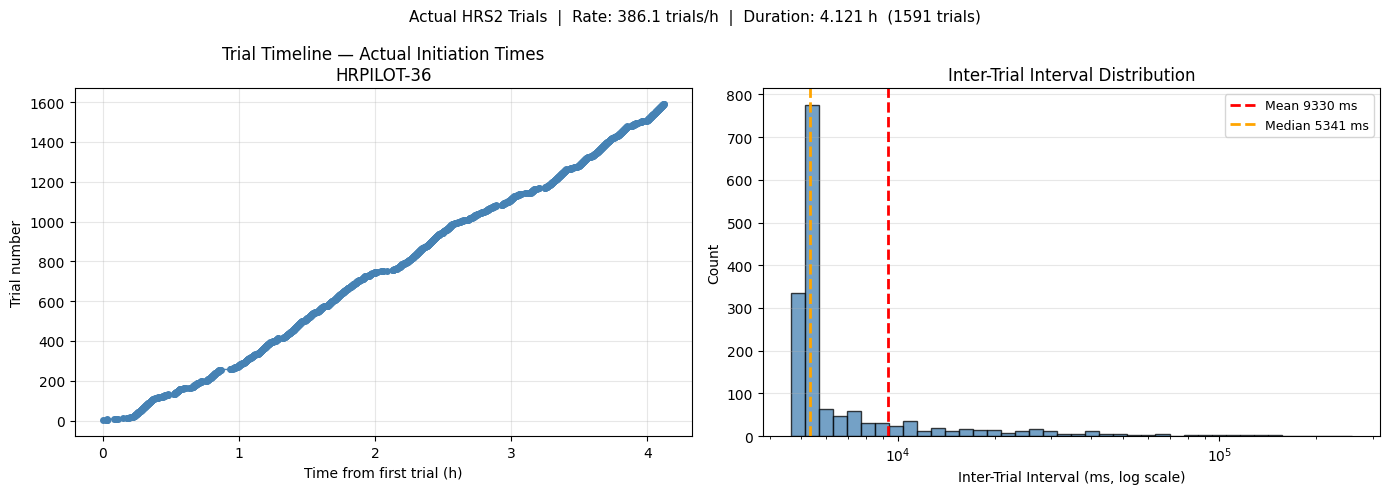

In [29]:
plot_amplitude_distribution(hrs2_trials, hrs2_header)
plot_actual_trial_timeline(hrs2_trials, header=hrs2_header)

# Section 6: Trial Quality Filter

Automatically detect and remove trials where the ADC sync pulse was missed or the stim onset could not be verified.  
The cleaned trial list replaces `hrs2_trials` for all downstream sections.

In [30]:
hrs2_trials = filter_failed_trials(
    hrs2_trials, hrs2_header, hrs2_emg_blocks,
    pre_ms=PRE_PLOT_MS, post_ms=POST_PLOT_MS,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

File version : 10  (pre-computed fields used)
Total trials : 1591
Passed       : 1591
Failed       : 0

No failed trials — all trials passed ADC-sync check.
Failed trials removed : 0
Trials remaining      : 1591


# Section 7: Waveform Analysis

Grand-averaged EMG waveforms and recruitment curve across all stimulation amplitudes.  
A polarity toggle appears automatically for dual-polarity sessions.

In [31]:
# ── Optional: Merged Amplitude Group Analysis ─────────────────────────────
# Pool multiple stimulation intensities into one merged group.
# MERGED_GROUPS is a list of lists, e.g.:
#   [[0.12, 0.13], [0.15, 0.16, 0.17]]  →  two merged groups
# Leave as [] to use the default (unmerged) grouping.
MERGED_GROUPS = []

if MERGED_GROUPS:
    _hrs2_trials_plot = build_merged_amp_groups(hrs2_trials, MERGED_GROUPS)
else:
    _hrs2_trials_plot = hrs2_trials


In [ ]:
plot_hrs2_analysis(
    _hrs2_trials_plot, hrs2_header,
    pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
    n_per_page=N_PER_PAGE,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    emg_blocks=hrs2_emg_blocks,
)

Loaded 45 amplitude groups across 8 page(s)  — dual-polarity session: 1456 normal, 135 reversed.
Double-click a subplot to zoom in. Ctrl-click to select multiple signals.


ToggleButtons(button_style='info', description='View:', options=(('Raw (mA)', 'raw'), ('Normalized (% Mmax)', …

Output()

HTML(value='<hr><b>Background EMG — selected amplitude / polarity group</b>')

Output()

HTML(value='<hr><b>H-wave Regression — selected amplitude / polarity group</b>')

Output()

# Section 8: Individual Trial Viewer

Interactive per-trial grid with page navigation and zoom.  
Use the signal overlays to inspect the ADC sync pulse and stimulator output for each trial.  
Double-click a subplot to zoom in; use the dropdown and **View trial** button to navigate.

In [33]:
plot_hrs2_trials(
    _hrs2_trials_plot, hrs2_header,
    pre_plot_ms=PRE_PLOT_MS, post_plot_ms=POST_PLOT_MS,
    n_per_page=N_PER_PAGE,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    emg_blocks=hrs2_emg_blocks,
)

Loaded 1456 trials across 243 page(s)  — dual-polarity session: 1456 normal, 135 reversed.
Sample rate: 10000 Hz  |  ms/sample: 0.1000
Stim waveform: available
Double-click a subplot to zoom in, or use the dropdown + 'View trial' button.


HTML(value='<hr><b>Background EMG — selected group</b>')

Output()

HTML(value='<hr><b>H:M Ratio Summary — selected group</b>')

Output()

HTML(value='<hr><b>H-wave Regression — selected group</b>')

Output()

# Section 9: Background EMG Distribution

Extract each trial's pre-stimulus background EMG grand mean and plot the distribution.  
For HRS2 v5+ files this uses the value stored directly in each trial; older files reconstruct it from the EMG blocks.  
The returned `state` dict (key `'trial_bg_gm'`) is passed to Section 10 for binning.

Trials: 1591  (stored: 1591, reconstructed: 0)
Background  Min=71.15  Q1=136.68  Median=158.75  Q3=174.84  Max=208.60 µV


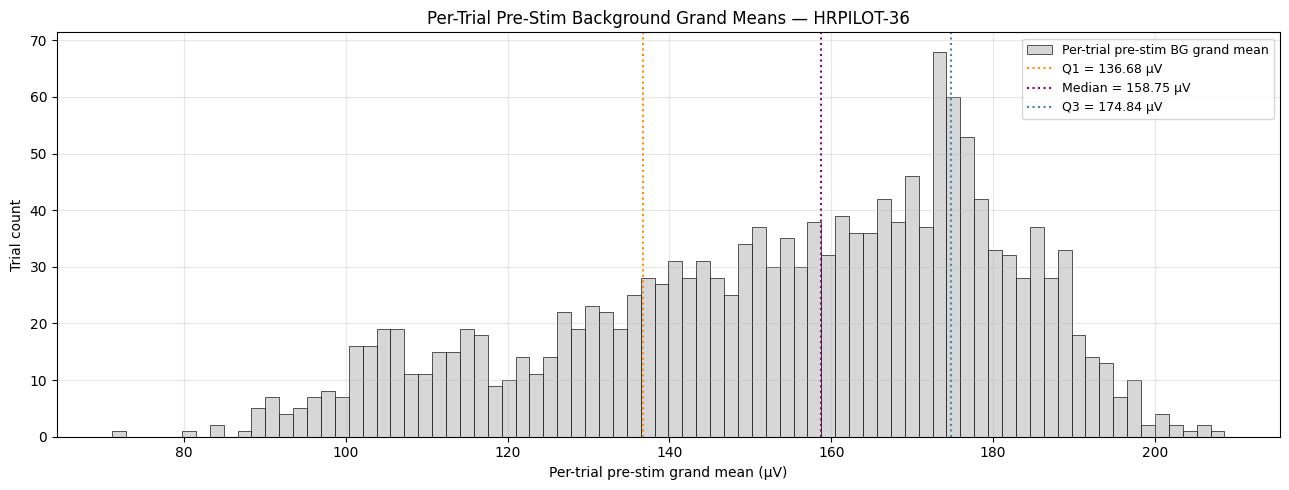

In [34]:
state = plot_background_grand_means(
    hrs2_trials, hrs2_emg_blocks, hrs2_header,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

# Section 10: EMG Activity Bins

**Optional subset filter** — restrict the analysis to a specific polarity and/or stimulation intensity
range. Set `FILTER_POLARITY` and/or `FILTER_INTENSITIES`, or leave both as `None` to include all trials.

**Bin definition** — set `BIN_RANGES = 'auto'` to automatically compute equal-count bin boundaries
from the filtered trial set, controlled by `N_BINS`. Or set `BIN_RANGES` to a list of manual `(lo, hi)` pairs.

`BIN_MODE` controls what metric is used for binning:
- `'EMG'` — pre-stim background grand mean (default)
- `'M_WAVE'` — M-wave MRA
- `'H_WAVE'` — H-wave MRA

In [35]:
# ── Subset filter (optional) ──────────────────────────────────────────
# FILTER_POLARITY  : 'normal' | 'reversed' | None  (None = all trials)
# FILTER_POLARITY = None
FILTER_POLARITY = None

# FILTER_INTENSITIES: None (all) | tuple (lo, hi) in mA | list of exact mA values
#   e.g.  (0.5, 2.0)   keeps trials with amplitude in [0.5, 2.0] mA
#   e.g.  [1.0, 1.5]   keeps only those exact amplitudes (±0.001 mA tolerance)
# FILTER_INTENSITIES = None

FILTER_INTENSITIES = None


#FILTER_POLARITY    = None    # 'normal' | 'reversed' | None
#FILTER_INTENSITIES = None    # (lo, hi) mA | [list of mA] | None
# ───────────────────────────────────────────────────────────────────────

# ── Bin definition ──────────────────────────────────────────────────────
BIN_MODE   = 'EMG' # can also do "H-Wave", "M-Wave", "H:M"
N_BINS     = 3       # bins to create when BIN_RANGES = 'auto'
BIN_RANGES = 'auto'  # 'auto' → equal-count | [(lo, hi), ...] → manual
#BIN_RANGES = [(50, 110), (110, 140), (140, 1000)]  # µV ranges
# ───────────────────────────────────────────────────────────────────────

analysis_trials, analysis_state = filter_trials(
    hrs2_trials, state,
    filter_polarity=FILTER_POLARITY,
    filter_intensities=FILTER_INTENSITIES,
)

if BIN_RANGES == 'auto':
    BIN_RANGES = compute_equal_bin_ranges(
        analysis_trials, BIN_MODE, N_BINS, analysis_state,
        sample_rate=recording_sample_rate or hrs1_header.sample_rate,
        pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
        m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
        h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    )

binned_trials, bin_labels, bin_colors, trial_bg_dict, bin_unit, pol_labels, _ = compute_trial_bins(
    analysis_trials,
    bin_mode=BIN_MODE,
    bin_ranges=BIN_RANGES,
    state=analysis_state,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
)

No filter applied — using all 1591 trials
Auto-bin: 3 equal-count bins  |  1591 trials  |  µV bg
  Bin 1: [71.15, 144.32)  →  531 trials
  Bin 2: [144.32, 170.64)  →  529 trials
  Bin 3: [170.64, 208.61)  →  531 trials
Dual-polarity session detected: 1456 normal, 135 reversed → analysing separately.
BIN_MODE = 'EMG'  |  Unit: µV bg
Bin                             Normal (0)    Reversed (1)
----------------------------------------------------------
Bin 1: 71.15–144.32 µV bg  [c=107.7, Δ73.17]  483           48          
Bin 2: 144.32–170.64 µV bg  [c=157.5, Δ26.32]  496           33          
Bin 3: 170.64–208.61 µV bg  [c=189.6, Δ37.97]  477           54          


# Section 11: Bin Overview

Averaged EMG waveforms for each bin overlaid on the same axes, plus M-wave MRA, H-wave MRA, and H:M ratio bar charts with mean ± SD.  
A polarity toggle appears automatically for dual-polarity sessions.

In [36]:
plot_bin_overview(
    binned_trials, bin_labels, bin_colors, pol_labels, hrs2_header,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    bin_ranges=BIN_RANGES, bin_unit=bin_unit,
)

# Section 12: Per-Bin Viewer

Select a polarity and bin, then click **Load bin viewer** to inspect that trial subset in detail:  
background EMG distribution, averaged waveforms + recruitment curve, and individual trial grid.

In [37]:
create_bin_viewer(
    binned_trials, bin_labels, bin_colors, pol_labels,
    hrs2_header, hrs2_emg_blocks, trial_bg_dict,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    pre_plot_ms=PRE_PLOT_MS, post_plot_ms=POST_PLOT_MS,
    pre_avg_ms=PRE_AVG_MS,   post_avg_ms=POST_AVG_MS,
    n_per_page=N_PER_PAGE,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
)

# Section 13: Bin Statistics

Per-bin × per-polarity numeric table: trial count, mean M-wave MRA, mean H-wave MRA, and mean H:M ratio.

In [38]:
print_bin_statistics(
    binned_trials, bin_labels, pol_labels,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
)

Polarity              Bin                                         n   M-Size µV   H-Size µV       H:M
-----------------------------------------------------------------------------------------------------
Normal (0)            Bin 1: 71.15–144.32 µV bg  [c=107.7, Δ73.17]    483      2199.0       633.4     0.303
Normal (0)            Bin 2: 144.32–170.64 µV bg  [c=157.5, Δ26.32]    496      2016.0       683.0     0.367
Normal (0)            Bin 3: 170.64–208.61 µV bg  [c=189.6, Δ37.97]    477      1897.5       642.6     0.369

Reversed (1)          Bin 1: 71.15–144.32 µV bg  [c=107.7, Δ73.17]     48      2094.0       676.5     0.342
Reversed (1)          Bin 2: 144.32–170.64 µV bg  [c=157.5, Δ26.32]     33      2013.5       734.8     0.396
Reversed (1)          Bin 3: 170.64–208.61 µV bg  [c=189.6, Δ37.97]     54      2084.2       668.7     0.358



# Section 14: Per-Trial DataFrame & Calculations

`trial_df` is a flat per-trial DataFrame with M/H size (µV) and H:M ratio computed from `analysis_trials`.  
Re-run if you change M/H windows or the analysis trial filter above.

In [39]:
import pandas as pd
import numpy as np
from helpers import get_trial_window as _gtw_df

# ── Build per-trial DataFrame from analysis_trials ─────────────────────────────
_sr_df    = recording_sample_rate or hrs1_header.sample_rate
_ms_ps_df = 1000.0 / _sr_df
_rows = []
for _i, _t in enumerate(analysis_trials):
    try:
        _tm, _emg, _, _, _ = _gtw_df(_t, PRE_AVG_MS, POST_AVG_MS, ms_per_sample=_ms_ps_df)
        _mm   = (_tm >= M_WAVE_START_MS) & (_tm <= M_WAVE_END_MS)
        _hm   = (_tm >= H_WAVE_START_MS) & (_tm <= H_WAVE_END_MS)
        _bg   = _tm < 0
        _bg_v = float(np.nanmean(np.abs(_emg[_bg]))) if _bg.any() else 0.0
        _mv   = float(np.nanmean(np.abs(_emg[_mm]))) - _bg_v if _mm.any() else float('nan')
        _hv   = float(np.nanmean(np.abs(_emg[_hm]))) - _bg_v if _hm.any() else float('nan')
        _hmr  = _hv / _mv if (_mv and _mv > 0) else float('nan')
    except Exception:
        _bg_v = _mv = _hv = _hmr = float('nan')
    _rows.append({
        'trial':       _i + 1,
        'stim_amp_ma': float(getattr(_t, 'stimulation_amplitude_ma', float('nan'))),
        'bg_mra_uv':   _bg_v,
        'm_size_uv':   _mv,
        'h_size_uv':   _hv,
        'hm_ratio':    _hmr,
    })

trial_df = pd.DataFrame(_rows)
print(f"trial_df: {len(trial_df)} rows  ({len(analysis_trials)} analysis_trials)")
trial_df.head(10)

trial_df: 1591 rows  (1591 analysis_trials)


,trial,stim_amp_ma,bg_mra_uv,m_size_uv,h_size_uv,hm_ratio
0,1,0.12,84.160950,2791.899353,99.453293,0.035622
1,2,0.12,174.550430,2834.270370,5.973206,0.002107
2,3,0.12,296.210754,2171.986023,-8.210052,-0.003780
3,4,0.12,179.029526,2385.028580,448.712234,0.188137
4,5,0.12,64.827354,2530.077675,260.042885,0.102781
5,6,0.12,26.357956,2727.479446,264.734909,0.097062
6,7,0.12,71.608688,2153.470413,231.419235,0.107463
7,8,0.12,370.256104,2548.022949,-110.571136,-0.043395
8,9,0.12,75.515663,2081.735069,306.662407,0.147311
9,10,0.12,68.757507,2303.067200,210.296173,0.091311


In [40]:
# ── Summary statistics ────────────────────────────────────────────────────────
trial_summary = pd.Series({
    'n_trials':      trial_df['trial'].count(),
    'm_size_mean':   trial_df['m_size_uv'].mean(),
    'm_size_std':    trial_df['m_size_uv'].std(),
    'h_size_mean':   trial_df['h_size_uv'].mean(),
    'h_size_std':    trial_df['h_size_uv'].std(),
    'hm_ratio_mean': trial_df['hm_ratio'].mean(),
    'hm_ratio_std':  trial_df['hm_ratio'].std(),
    'bg_mra_mean':   trial_df['bg_mra_uv'].mean(),
}, name='value').round(3).to_frame()
trial_summary

,value
n_trials,1591.000
m_size_mean,2040.644
m_size_std,425.673
h_size_mean,656.235
h_size_std,288.739
hm_ratio_mean,0.348
hm_ratio_std,0.202
bg_mra_mean,153.950


In [41]:
# ── Custom calculations — edit this cell freely ───────────────────────────────
# Examples:

# Filter by stimulus amplitude
# amp_subset = trial_df[trial_df['stim_amp_ma'] == 1.0]

# Coefficient of variation (%) for H-size
# cv_h = trial_df['h_size_uv'].std() / trial_df['h_size_uv'].mean() * 100
# print(f"H-wave Size CV: {cv_h:.1f}%")

# Correlation between background MRA and H-wave size
# trial_df[['bg_mra_uv', 'h_size_uv']].corr()

# Export to CSV
# trial_df.to_csv('trial_data.csv', index=False)
# trial_summary.to_csv('trial_summary.csv')

print("trial_df and trial_summary are ready.  Edit this cell to run your calculations.")

trial_df and trial_summary are ready.  Edit this cell to run your calculations.


### Recording Settings DataFrame

`settings_df` captures the app-side stimulation/window settings that were active for each
(recording, stage) — parsed from the `*.settings.json` sidecar written next to each binary
data file by newer H-Reflex App recordings (sweep range, M/H-wave windows, thresholds,
polarity, pulse-train parameters, etc). Stages recorded before the app wrote sidecars still
get a row here; their settings columns are simply NaN.

In [42]:
# ── Build settings DataFrame from *.settings.json sidecars ───────────────────────
settings_df = build_settings_dataframe(_all_recordings)
_meta_cols = {'recording', 'stage', 'stage_key', 'subject_id', 'session_start',
              'app_version', 'file_version', 'sample_rate_hz', 'n_trials'}
_setting_cols = [c for c in settings_df.columns if c not in _meta_cols]
_n_with_settings = int(settings_df[_setting_cols].notna().any(axis=1).sum()) if _setting_cols else 0
print(f"settings_df: {len(settings_df)} rows  |  {settings_df['recording'].nunique()} recording(s)  |  "
      f"{_n_with_settings}/{len(settings_df)} stage(s) have a settings.json sidecar")
settings_df.head(10)

settings_df: 1 rows  |  1 recording(s)  |  1/1 stage(s) have a settings.json sidecar


,recording,stage,stage_key,subject_id,session_start,app_version,file_version,sample_rate_hz,n_trials,user_min_stimulation_amplitude,...,m_wave_max_intensity_ma,m_wave_min_intensity_ma,user_m_wave_window_start_time_milliseconds,user_m_wave_window_end_time_milliseconds,user_h_wave_window_start_time_milliseconds,user_h_wave_window_end_time_milliseconds,manual_min_threshold,manual_max_threshold,reversed_polarity,fixed_stimulation_amplitude_ma
0,CM2 HRPILOT-36 250US,Control Mode (.hrs2),control_mode,HRPILOT-36,2026-09-15 10:51:26.340609,H-Reflex App Version 3,10,57700.0,1591,0.12,...,0.165,0.1,2.2,4.2,6.5,11.5,75.0,235.0,False,0.12


### Save Analysis to Disk

Bundle `trial_df`, `trial_summary`, and `settings_df` into a single pickle file so this analysis
can be reloaded later without re-reading the raw binary recordings. Call
`save_analysis_pickle()` whenever you want a snapshot — nothing is saved automatically.

In [43]:
# ── Save analysis DataFrames to a pickle file (on demand) ──────────────
import pickle
from datetime import datetime as _dt

def save_analysis_pickle(path=None, **extra_frames):
    """Pickle trial_df, trial_summary, and settings_df (plus any extra_frames) to *path*.

    path=None auto-names the file from the current timestamp in the working directory.
    Returns the path written to.
    """
    _path = path or f"post_hoc_analysis_{_dt.now():%Y%m%d_%H%M%S}.pkl"
    _bundle = {'trial_df': trial_df, 'trial_summary': trial_summary, 'settings_df': settings_df, **extra_frames}
    with open(_path, 'wb') as _f:
        pickle.dump(_bundle, _f)
    print(f"Saved {list(_bundle.keys())} -> {_path}")
    return _path

print("Ready. Call save_analysis_pickle() to pickle trial_df / trial_summary / settings_df to disk,")
print("or save_analysis_pickle('my_analysis.pkl') to choose the filename.")

Ready. Call save_analysis_pickle() to pickle trial_df / trial_summary / settings_df to disk,
or save_analysis_pickle('my_analysis.pkl') to choose the filename.


# Section 14: H:M Ratio Summary

Box plot and histogram of the H:M ratio split by stimulation polarity group.  
Shows distribution shape, SD, CV, and 20th/80th percentiles.

Dual-polarity session detected: 1456 normal, 135 reversed → analysing separately.


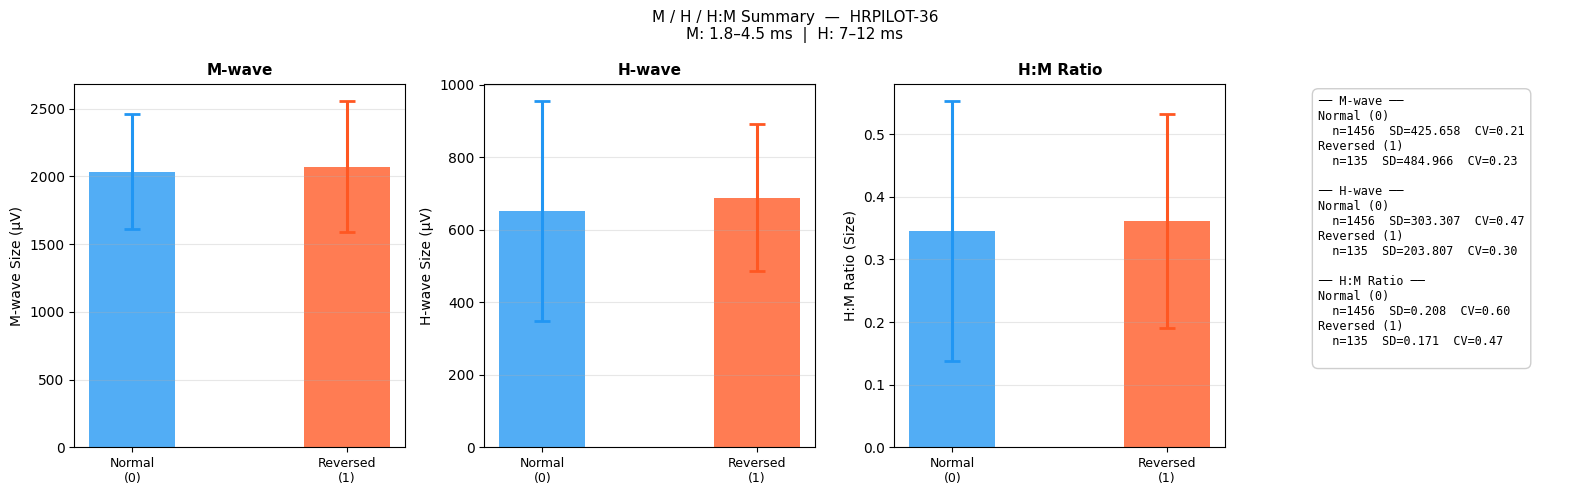

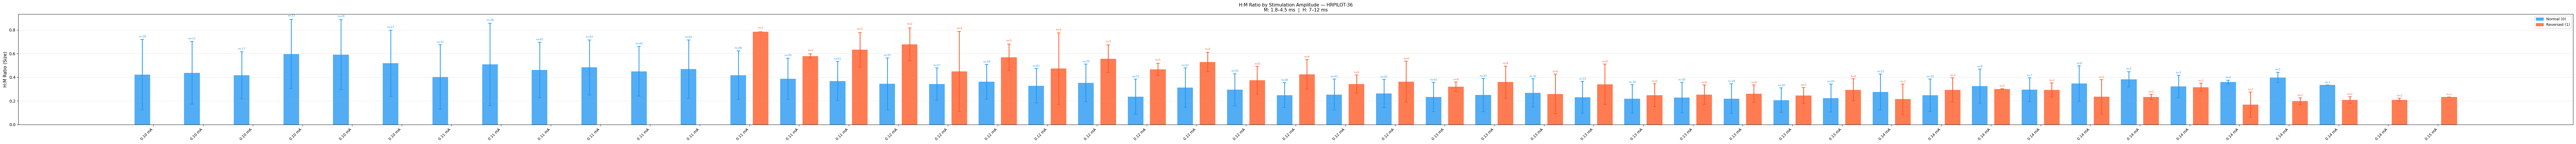

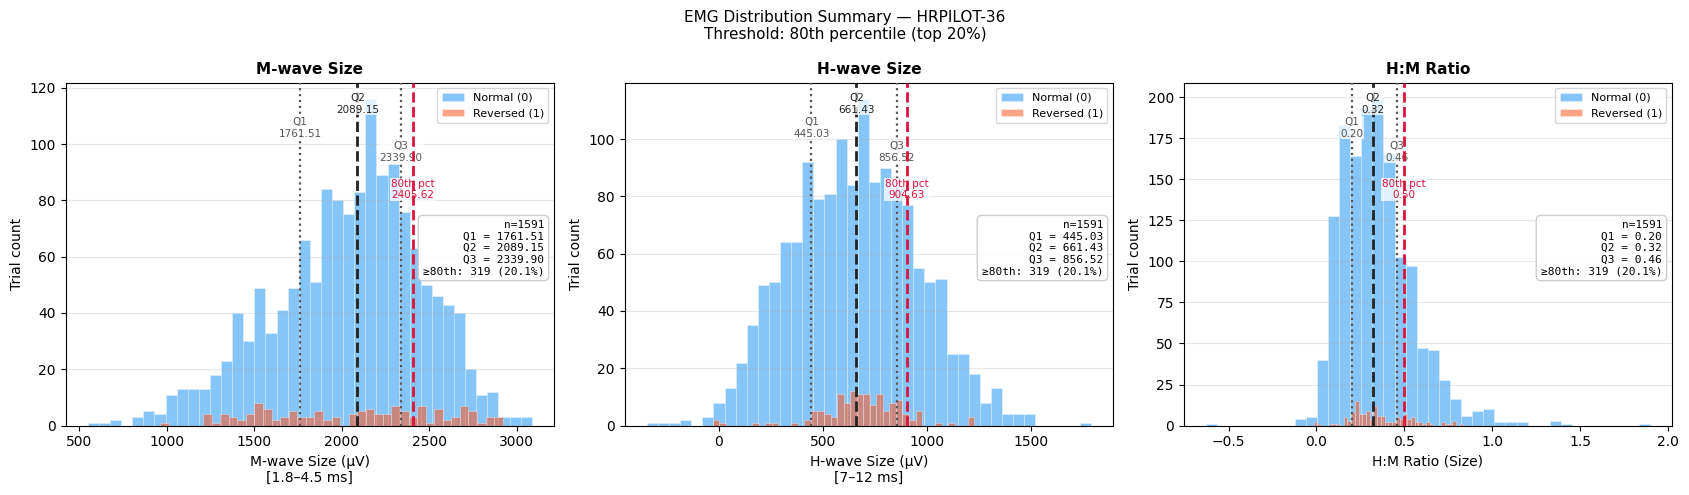

In [44]:
plot_hm_ratio_summary(
    split_trials_by_polarity(analysis_trials), hrs2_header,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

# Section 15: SNR Analysis (RMS)

Per-amplitude signal-to-noise ratio using the RMS of the M-wave and H-wave windows against a pre-stim RMS background window.

| Metric | Formula |
|---|---|
| SNR_M | RMS(M-wave) / RMS(pre-stim BG) |
| SNR_H | RMS(H-wave) / RMS(pre-stim BG) |
| SNR_H:M | (RMS_H / RMS_M) / RMS(pre-stim BG) |

Adjust `BG_PRE_MS` to change the background window length.

SNR Analysis — HRPILOT-36
  M window : 1.8–4.5 ms
  H window : 7–12 ms
  BG window: -15–0 ms (pre-stim)

Metric                 n      Mean    Median        SD      CV
--------------------------------------------------------------
  SNR_M  (M/BG)     1591    14.281    13.129     6.240   0.437
  SNR_H  (H/BG)     1591     5.115     4.740     2.328   0.455
  SNR_HM (H:M/BG)   1591     0.002     0.002     0.001   0.557


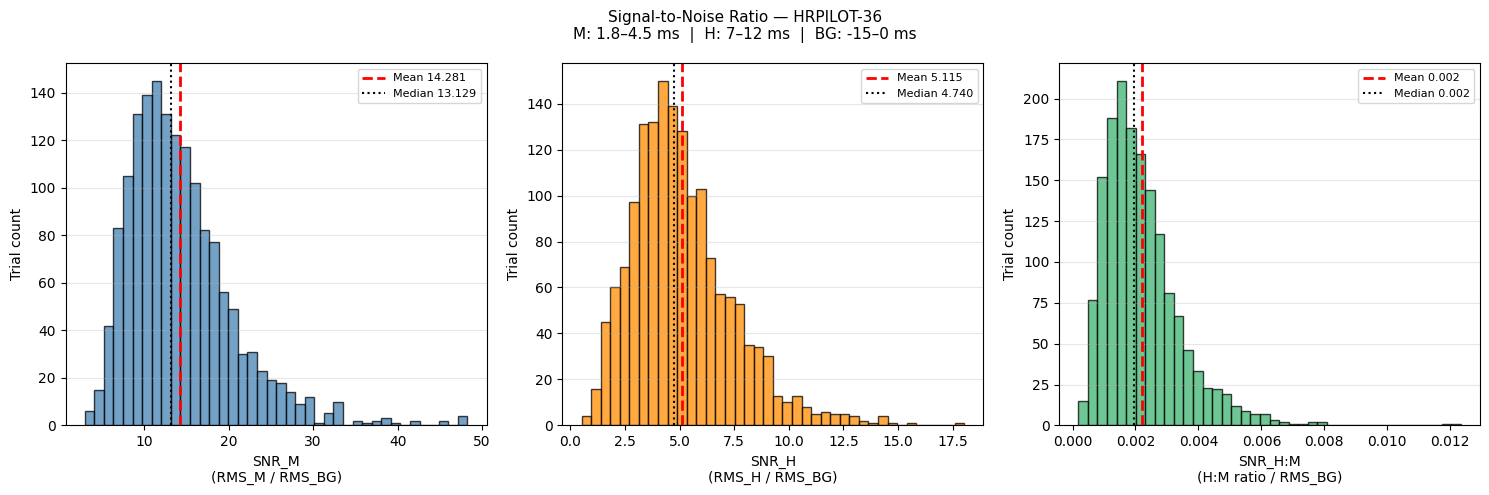

In [45]:
BG_PRE_MS = 15.0  # ms of pre-stim signal used as noise baseline

snr_results = compute_snr_analysis(
    hrs2_trials, hrs2_header,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    bg_pre_ms=BG_PRE_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

# Section 16: SNR Analysis (MRA)

Same analysis as Section 15 but uses **Mean Rectified Average** (`mean(|signal|)`) instead of RMS — more robust to asymmetric waveforms.

| Metric | Formula |
|---|---|
| MRA-SNR_M | MRA(M-wave) / MRA(pre-stim BG) |
| MRA-SNR_H | MRA(H-wave) / MRA(pre-stim BG) |
| MRA-SNR_H:M | (MRA_H / MRA_M) / MRA(pre-stim BG) |

MRA-SNR Analysis — HRPILOT-36
  M window : 1.8–4.5 ms
  H window : 7–12 ms
  BG window: -15–0 ms (pre-stim)

Metric                   n      Mean    Median        SD      CV
----------------------------------------------------------------
  MRA-SNR_M  (M/BG)   1591    16.104    14.664     7.114   0.442
  MRA-SNR_H  (H/BG)   1591     5.786     5.335     2.720   0.470
  MRA-SNR_HM (H:M/BG)  1591     0.003     0.002     0.002   0.578


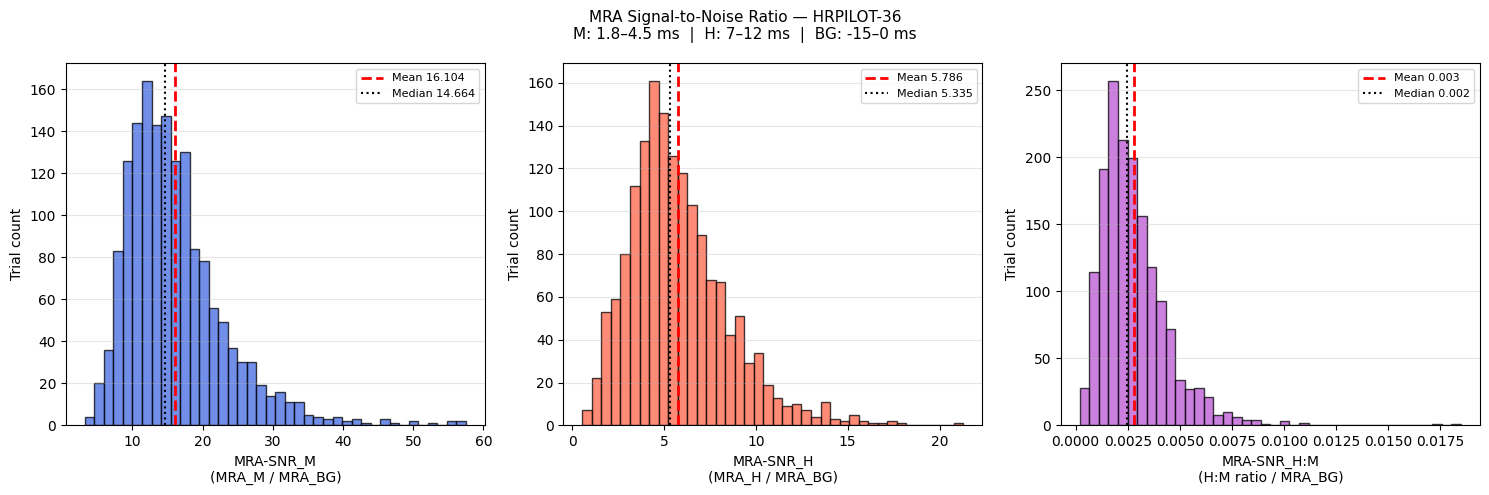

In [46]:
mra_snr_results = compute_mra_snr_analysis(
    hrs2_trials, hrs2_header,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    bg_pre_ms=BG_PRE_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)